# Residual Signal Finder on UCI credit data

This notebook explores the public functionality of `ResidualSignalFinder` on a real UCI Machine Learning Repository dataset: **Default of Credit Card Clients**. The dataset is credit-related, has 30,000 observations, and provides 23 modeling features after dropping the ID column.

Workflow:

1. Load the saved UCI dataset from `data/default_of_credit_card_clients.csv`.
2. Fit a simple GLM-style baseline model using all features to predict default probability.
3. Pass those baseline predictions into `ResidualSignalFinder` as `y_pred`. Because the target is binary, the finder models `y_true` directly and includes `y_pred` as a control feature.
4. Inspect CV, holdout, group CV, bootstrap, interactions, plots, reports, and v1 validation behavior.


## Setup

The path setup lets the notebook run from the repository root or from inside `notebooks/`.


In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for path in [PROJECT_ROOT / 'src', PROJECT_ROOT]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

PROJECT_ROOT


WindowsPath('C:/Users/amsac/Desktop/repos/modeling-tools')

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from pe_tools.signal_finder import ResidualSignalFinder

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)


## Load the UCI credit dataset

The target is `default_next_month`. All remaining columns are numeric features, including several numerically encoded categorical fields (`sex`, `education`, and `marriage`). For v1 of the residual finder, this is acceptable because the implementation explicitly accepts numeric columns only.


In [21]:
DATA_PATH = PROJECT_ROOT / 'data' / 'default_of_credit_card_clients.csv'
credit = pd.read_csv(DATA_PATH)
target_col = 'default_next_month'
feature_cols = [column for column in credit.columns if column != target_col]

X_all = credit.loc[:, feature_cols].copy()
y_all = credit[target_col].astype(float).rename(target_col)

print(f'Rows: {len(credit):,}')
print(f'Feature count: {len(feature_cols)}')
display(X_all.head())
display(y_all.value_counts(normalize=True).rename('target_rate'))


Rows: 30,000
Feature count: 23


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,bill_amt1,bill_amt2,bill_amt3,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679


default_next_month
0.0    0.7788
1.0    0.2212
Name: target_rate, dtype: float64

## Create a fast modeling sample and evaluation splits

The full CSV remains available in `data/`, but this notebook uses a stratified 6,000-row sample so the full feature tour runs quickly. The explicit split labels are reused for holdout mode.


In [22]:
analysis_frame = train_test_split(
    credit,
    train_size=6_000,
    stratify=credit[target_col],
    random_state=42,
)[0].sort_index()

train_valid, holdout_rows = train_test_split(
    analysis_frame,
    test_size=0.15,
    stratify=analysis_frame[target_col],
    random_state=42,
)
train_rows, validation_rows = train_test_split(
    train_valid,
    test_size=0.1765,
    stratify=train_valid[target_col],
    random_state=42,
)

X = analysis_frame.loc[:, feature_cols].copy()
y_true = analysis_frame[target_col].astype(float).rename(target_col)
split_col = pd.Series('train', index=X.index, name='split')
split_col.loc[validation_rows.index] = 'validation'
split_col.loc[holdout_rows.index] = 'holdout'

display(split_col.value_counts().rename('row_count'))


split
train         4199
validation     901
holdout        900
Name: row_count, dtype: int64

## Build sample weights

Weights are optional, but they are useful here to balance the minority default class while slightly emphasizing larger credit limits.


In [23]:
default_rate = float(y_true.mean())
class_weight = np.where(
    y_true.eq(1),
    0.5 / default_rate,
    0.5 / (1.0 - default_rate),
)
limit_weight = (X['limit_bal'] / X['limit_bal'].median()).clip(0.25, 4.0)
sample_weight = pd.Series(
    class_weight * limit_weight.to_numpy(),
    index=X.index,
    name='sample_weight',
)

display(sample_weight.describe())


count    6000.000000
mean        1.114565
std         1.143140
min         0.160496
25%         0.366849
50%         0.807407
75%         1.375684
max         9.042954
Name: sample_weight, dtype: float64

## Fit a simple GLM baseline

The baseline is intentionally plain: standardized features plus logistic regression. It is GLM-like, uses all modeling features, and produces default probabilities. Those probabilities become the residual finder's `y_pred`; for this binary target, the finder then models `y_true` with that prediction included as a control variable. This walkthrough also enables `offbalance=True`, which shifts held-out predictions to the target level within each split so binned errors are easier to compare.


In [24]:
train_mask = split_col.eq('train')
eval_mask = ~train_mask
baseline_glm = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1_000, solver='lbfgs'),
)
baseline_glm.fit(
    X.loc[train_mask],
    y_true.loc[train_mask],
    logisticregression__sample_weight=sample_weight.loc[train_mask],
)

glm_y_pred = pd.Series(
    baseline_glm.predict_proba(X)[:, 1],
    index=X.index,
    name='glm_default_probability',
)
holdout_auc = roc_auc_score(y_true.loc[eval_mask], glm_y_pred.loc[eval_mask])
print(f'GLM validation plus holdout ROC AUC: {holdout_auc:.3f}')
display(
    pd.DataFrame({'y_true': y_true, 'glm_y_pred': glm_y_pred})
    .assign(residual=lambda frame: frame['y_true'] - frame['glm_y_pred'])
    .head()
)


GLM validation plus holdout ROC AUC: 0.719


,y_true,glm_y_pred,residual
5,0.0,0.570879,-0.570879
13,1.0,0.545202,0.454798
24,0.0,0.493582,-0.493582
40,0.0,0.002966,-0.002966
41,0.0,0.513133,-0.513133


## Default CV residual scan

The default split strategy is shuffled K-fold CV. Since `y_true` is 0/1, classification behavior is detected automatically: the residual model is fit to the target while controlling for the GLM prediction. Public feature importance then reports the original signal features, not the internal prediction control. With `offbalance=True`, each split's predictions are leveled to the split target mean before scoring and diagnostics.


In [25]:
cv_result = ResidualSignalFinder(
    model_type='xgboost',
    max_depth=1,
    n_estimators=80,
    learning_rate=0.05,
    n_bins=10,
    offbalance=True,
    split_strategy='cv',
    n_splits=5,
    random_state=42,
).fit(
    X=X,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
)

print(cv_result.metadata)
display(cv_result.residual_model_score)
display(cv_result.fold_scores)
display(cv_result.feature_importance.head(12))
display(cv_result.feature_stability.head(12))


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\883689050.py:11: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


{'model_type': 'xgboost', 'max_depth': 1, 'n_estimators': 80, 'learning_rate': 0.05, 'n_bins': 10, 'split_strategy': 'cv', 'n_splits': 5, 'n_repeats': 1, 'sample_fraction': 0.8, 'offbalance': True, 'stratify_col': None, 'group_col': None, 'random_state': 42, 'sample_weight_used': True, 'task_type': 'binary_classification', 'model_target': 'y_true', 'residuals_definition': 'y_true - y_pred', 'prediction_control_column': '__y_pred_control__', 'warnings': ['Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.']}


{'mean_train_r2': 0.20428505635113284,
 'mean_test_r2': 0.1820417917300908,
 'std_test_r2': 0.012695853634249457}

,fold,train_r2,test_r2,validation_score,train_size,test_size,test_groups
0,0,0.205449,0.181883,0.181883,4800,1200,()
1,1,0.208108,0.167715,0.167715,4800,1200,()
2,2,0.199991,0.196911,0.196911,4800,1200,()
3,3,0.199179,0.195624,0.195624,4800,1200,()
4,4,0.208697,0.168075,0.168075,4800,1200,()


,feature,importance,importance_type
0,pay_0,63.427958,gain
1,pay_amt2,15.931639,gain
2,pay_4,14.385761,gain
3,pay_amt5,13.588072,gain
4,pay_3,11.396043,gain
5,pay_2,9.436436,gain
6,pay_6,9.348903,gain
7,pay_amt6,8.602635,gain
8,limit_bal,8.062664,gain
9,pay_amt1,7.153180,gain


,feature,mean_importance,std_importance,mean_rank,rank_std,top_1_rate,top_3_rate,selected_rate
0,pay_0,63.427958,2.231555,1.0,0.000000,1.0,1.0,1.0
1,pay_amt2,15.931639,2.051884,3.6,1.140175,0.0,0.4,1.0
2,pay_4,14.385761,4.548416,4.4,2.302173,0.0,0.4,1.0
3,pay_amt5,13.588072,3.227778,5.4,2.073644,0.0,0.2,1.0
4,pay_3,11.396043,10.880729,9.4,9.685040,0.0,0.6,0.6
5,pay_2,9.436436,12.619097,12.0,7.516648,0.0,0.2,0.6
6,pay_6,9.348903,5.419874,9.0,5.700877,0.0,0.0,0.8
7,pay_amt6,8.602635,5.131016,9.8,6.978539,0.0,0.0,0.8
8,limit_bal,8.062664,1.425698,9.2,1.483240,0.0,0.0,1.0
9,pay_amt1,7.153180,6.978742,11.4,7.924645,0.0,0.0,0.6


In [26]:
pd.testing.assert_series_equal(cv_result.residuals, y_true - glm_y_pred, check_names=False)
cv_result.residuals.describe()


count    6000.000000
mean       -0.234927
std         0.391018
min        -0.985092
25%        -0.491982
50%        -0.383080
75%        -0.152805
max         0.996268
Name: residual, dtype: float64

## Stratified CV scan

When `stratify_col` is provided, the finder bins that numeric column and uses `StratifiedKFold`. This can be handy when a feature such as credit limit should be balanced across folds.


In [ ]:
stratified_result = ResidualSignalFinder(
    model_type='xgboost',
    max_depth=1,
    n_estimators=40,
    learning_rate=0.05,
    offbalance=True,
    split_strategy='cv',
    stratify_col='limit_bal',
    n_splits=4,
    random_state=42,
).fit(
    X=X,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
)

display(stratified_result.fold_scores)
display(stratified_result.feature_importance.head(8))


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\212076472.py:11: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


,fold,train_r2,test_r2,validation_score,train_size,test_size,test_groups
0,0,0.187145,0.157150,0.157150,4500,1500,()
1,1,0.184038,0.164417,0.164417,4500,1500,()
2,2,0.178645,0.176988,0.176988,4500,1500,()
3,3,0.169690,0.195498,0.195498,4500,1500,()


,feature,importance,importance_type
0,pay_0,49.828335,gain
1,pay_2,22.341518,gain
2,pay_5,8.977459,gain
3,pay_3,8.881362,gain
4,pay_6,7.986377,gain
5,limit_bal,3.696906,gain
6,pay_4,2.725202,gain
7,age,0.000000,gain


## Binned diagnostics

Each feature gets a binned diagnostics table using held-out fold predictions where available. These tables power the plotting and report helpers.


In [41]:
top_feature = cv_result.feature_importance.iloc[0]['feature']
print(f'Top feature: {top_feature}')
display(cv_result.binned_diagnostics[top_feature])


Top feature: pay_0


,bin,n_obs,feature_mean,actual_mean,predicted_mean,error_mean
0,"(-2.001, -1.0]",1669,-1.330737,0.157579,0.348160,-0.190581
1,"(-1.0, 0.0]",2941,0.000000,0.125128,0.336050,-0.210922
2,"(0.0, 1.0]",764,1.000000,0.341623,0.584951,-0.243328
3,"(1.0, 2.0]",531,2.000000,0.687382,0.812415,-0.125033
4,"(2.0, 8.0]",95,3.842105,0.736842,0.881857,-0.145015


## Plot top residual signals

`plot_top_residual_signals` returns Matplotlib `Figure` objects. It only saves files when `save_dir` is provided.


pay_0 Figure


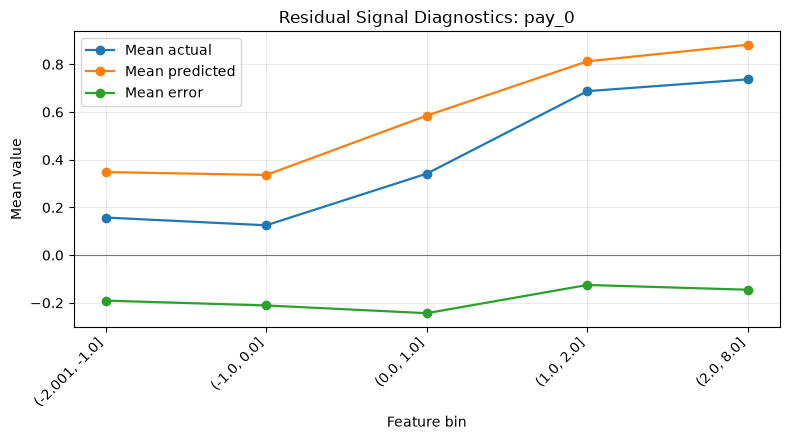

pay_amt2 Figure


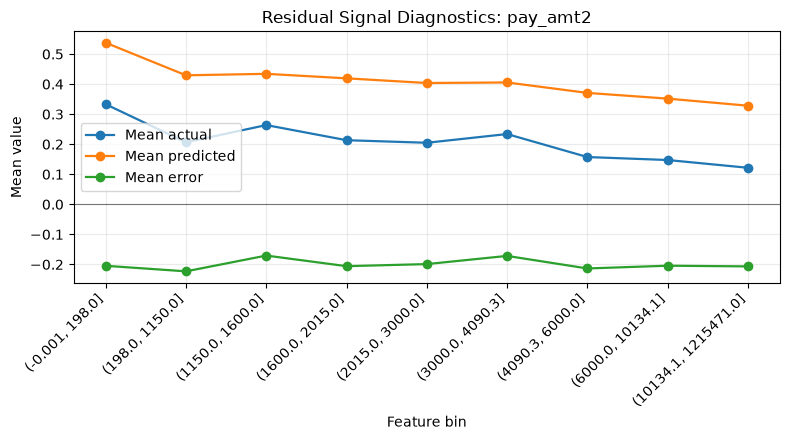

pay_4 Figure


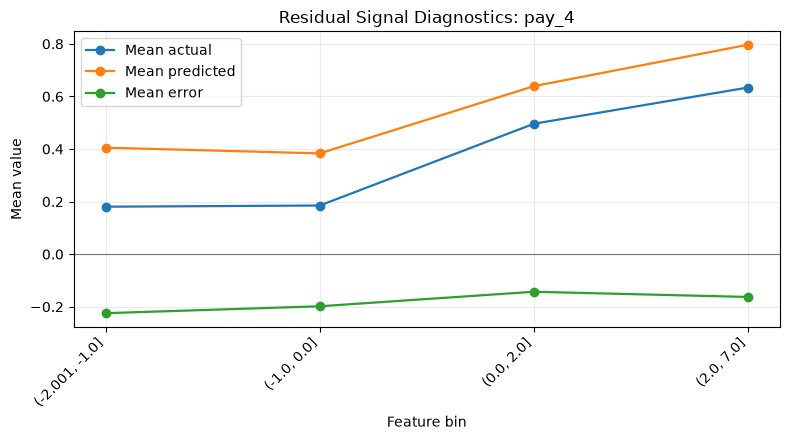

In [ ]:
figures = cv_result.plot_top_residual_signals(top_n=3)
for feature, figure in figures.items():
    print(feature, type(figure).__name__)
    display(figure)
    plt.close(figure)

## Holdout scan

Holdout mode uses explicit `train`, `validation`, and `holdout` labels. The residual model is fit on `train` and scored on each available evaluation split.


In [30]:
holdout_result = ResidualSignalFinder(
    model_type='xgboost',
    max_depth=1,
    n_estimators=80,
    learning_rate=0.05,
    offbalance=True,
    split_strategy='holdout',
    random_state=42,
).fit(
    X=X,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
    split_col=split_col,
)

display(holdout_result.fold_scores)
display(holdout_result.residual_model_score)
display(holdout_result.feature_importance.head(12))


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\2028757198.py:9: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


,fold,split,train_r2,test_r2,validation_score,train_size,test_size
0,0,validation,0.197032,0.182229,0.182229,4199,901
1,1,holdout,0.197032,0.232020,0.232020,4199,900


{'train_r2': 0.19703241021042794,
 'mean_test_r2': 0.20712455874677171,
 'std_test_r2': 0.024895609110270778,
 'validation_r2': 0.18222894963650094,
 'holdout_r2': 0.2320201678570425}

,feature,importance,importance_type
0,pay_0,43.617733,gain
1,pay_amt2,15.242692,gain
2,pay_amt5,14.957372,gain
3,pay_2,12.172864,gain
4,pay_amt6,11.468360,gain
5,pay_4,9.987033,gain
6,pay_amt1,8.881818,gain
7,pay_6,6.534008,gain
8,bill_amt1,6.043053,gain
9,age,0.000000,gain


## Group CV scan

Group CV requires a numeric grouping column inside `X` for v1. This example groups by age decile, and the finder drops the group column from model features before fitting.


In [31]:
age_group = pd.qcut(X['age'], q=5, labels=False, duplicates='drop').astype(int)
X_grouped = X.assign(age_group=age_group)
group_result = ResidualSignalFinder(
    model_type='random_forest',
    max_depth=2,
    n_estimators=60,
    offbalance=True,
    split_strategy='group_cv',
    group_col='age_group',
    n_splits=5,
    random_state=42,
).fit(
    X=X_grouped,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
)

group_columns = ['fold', 'test_groups', 'train_size', 'test_size', 'test_r2']
display(group_result.fold_scores[group_columns])
display(group_result.feature_importance.head(12))
group_feature_excluded = 'age_group' not in set(group_result.feature_importance['feature'])
print('Group feature excluded from model:', group_feature_excluded)


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\1722851033.py:12: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


,fold,test_groups,train_size,test_size,test_r2
0,0,"(2,)",4622,1378,0.147560
1,1,"(0,)",4679,1321,0.220682
2,2,"(4,)",4816,1184,0.185657
3,3,"(1,)",4897,1103,0.208393
4,4,"(3,)",4986,1014,0.183632


,feature,importance,importance_type
0,pay_0,0.584963,gain
1,bill_amt1,0.041861,gain
2,pay_amt2,0.030083,gain
3,pay_amt6,0.022069,gain
4,pay_amt5,0.017804,gain
5,pay_amt1,0.009249,gain
6,bill_amt4,0.007920,gain
7,bill_amt3,0.004321,gain
8,pay_2,0.003747,gain
9,pay_5,0.003115,gain


Group feature excluded from model: True


## Bootstrap scan

Bootstrap mode repeatedly samples training rows and scores out-of-bag rows when available. This gives another view of feature stability.


In [32]:
bootstrap_result = ResidualSignalFinder(
    model_type='xgboost',
    max_depth=1,
    n_estimators=60,
    learning_rate=0.05,
    offbalance=True,
    split_strategy='bootstrap',
    n_repeats=10,
    sample_fraction=0.8,
    random_state=42,
).fit(
    X=X,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
)

display(bootstrap_result.fold_scores)
display(bootstrap_result.feature_stability.head(12))


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\3783890192.py:11: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


,fold,repeat,train_r2,test_r2,validation_score,train_size,test_size
0,0,0,0.189434,0.157408,0.157408,4800,2687
1,1,1,0.197877,0.178106,0.178106,4800,2704
2,2,2,0.196566,0.177030,0.177030,4800,2689
3,3,3,0.224546,0.163228,0.163228,4800,2687
4,4,4,0.185393,0.199389,0.199389,4800,2664
5,5,5,0.189287,0.179176,0.179176,4800,2694
6,6,6,0.193309,0.181976,0.181976,4800,2739
7,7,7,0.182223,0.192939,0.192939,4800,2712
8,8,8,0.203702,0.174358,0.174358,4800,2663
9,9,9,0.205499,0.174092,0.174092,4800,2715


,feature,mean_importance,std_importance,mean_rank,rank_std,top_1_rate,top_3_rate,selected_rate
0,pay_0,67.248904,12.055754,1.0,0.000000,1.0,1.0,1.0
1,pay_amt5,16.571768,8.060390,6.3,5.578729,0.0,0.3,0.9
2,pay_amt2,13.758055,8.082856,8.0,6.976150,0.0,0.2,0.8
3,pay_4,13.664641,9.739228,8.7,7.227263,0.0,0.3,0.7
4,pay_2,13.289867,13.803743,9.7,7.303728,0.0,0.3,0.6
5,pay_amt1,11.507799,8.220265,9.6,7.763161,0.0,0.1,0.7
6,pay_amt3,10.706693,11.841693,12.1,9.158481,0.0,0.3,0.5
7,pay_amt4,9.832835,8.955361,11.6,8.194849,0.0,0.0,0.6
8,pay_5,8.248794,11.176158,12.6,8.154072,0.0,0.3,0.4
9,pay_amt6,5.861207,9.836151,16.7,8.667308,0.0,0.2,0.3


## Interaction scan with `max_depth=2`

When `max_depth=2`, the finder attempts conservative SHAP interaction detection if `shap` is installed. If SHAP is unavailable, metadata records a warning and `interaction_importance` remains empty.


In [33]:
interaction_result = ResidualSignalFinder(
    model_type='xgboost',
    max_depth=2,
    n_estimators=80,
    learning_rate=0.05,
    offbalance=True,
    split_strategy='cv',
    n_splits=3,
    random_state=42,
).fit(
    X=X,
    y_true=y_true,
    y_pred=glm_y_pred,
    sample_weight=sample_weight,
)

display(interaction_result.metadata.get('warnings', []))
display(interaction_result.interaction_importance.head(12))


C:\Users\amsac\AppData\Local\Temp\ipykernel_24536\1088668959.py:10: UserWarning: Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.
  ).fit(


['Binary classification target detected; ResidualSignalFinder will model y_true directly with y_pred included as a control feature because y_true - y_pred residuals are less informative for classification.']

,feature_1,feature_2,importance,rank
0,limit_bal,pay_amt5,0.002218,1
1,pay_0,bill_amt1,0.002198,2
2,pay_0,pay_amt5,0.001838,3
3,pay_0,pay_2,0.001833,4
4,limit_bal,pay_amt1,0.001675,5
5,pay_0,pay_5,0.001637,6
6,pay_0,pay_3,0.001244,7
7,limit_bal,pay_amt2,0.000903,8
8,pay_0,pay_amt4,0.000766,9
9,pay_0,pay_amt2,0.000761,10


## Interaction plots

For the top detected interactions, the plotter stores three-panel heatmaps: mean actual target, mean predicted target, and mean error across two-dimensional feature bins.


Saved interaction plot: notebooks\outputs\interaction_plots\limit_bal__x__pay_amt5_interaction.png


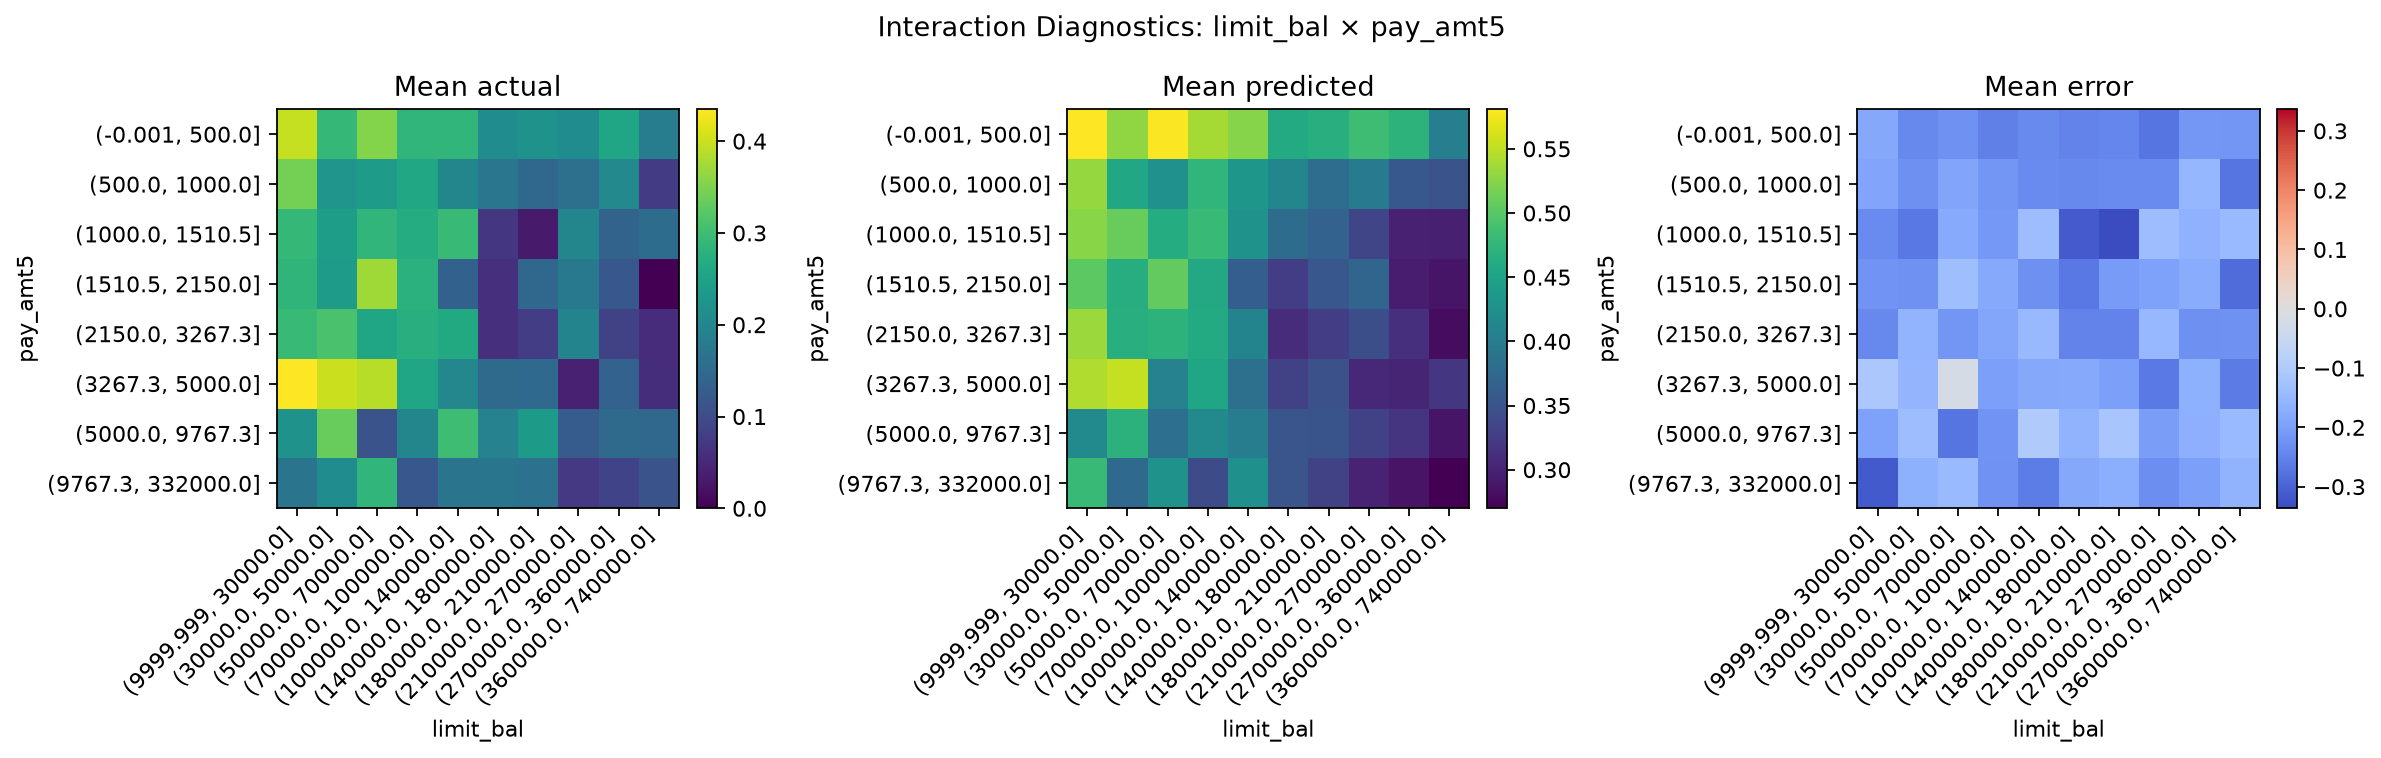

Saved interaction plot: notebooks\outputs\interaction_plots\pay_0__x__bill_amt1_interaction.png


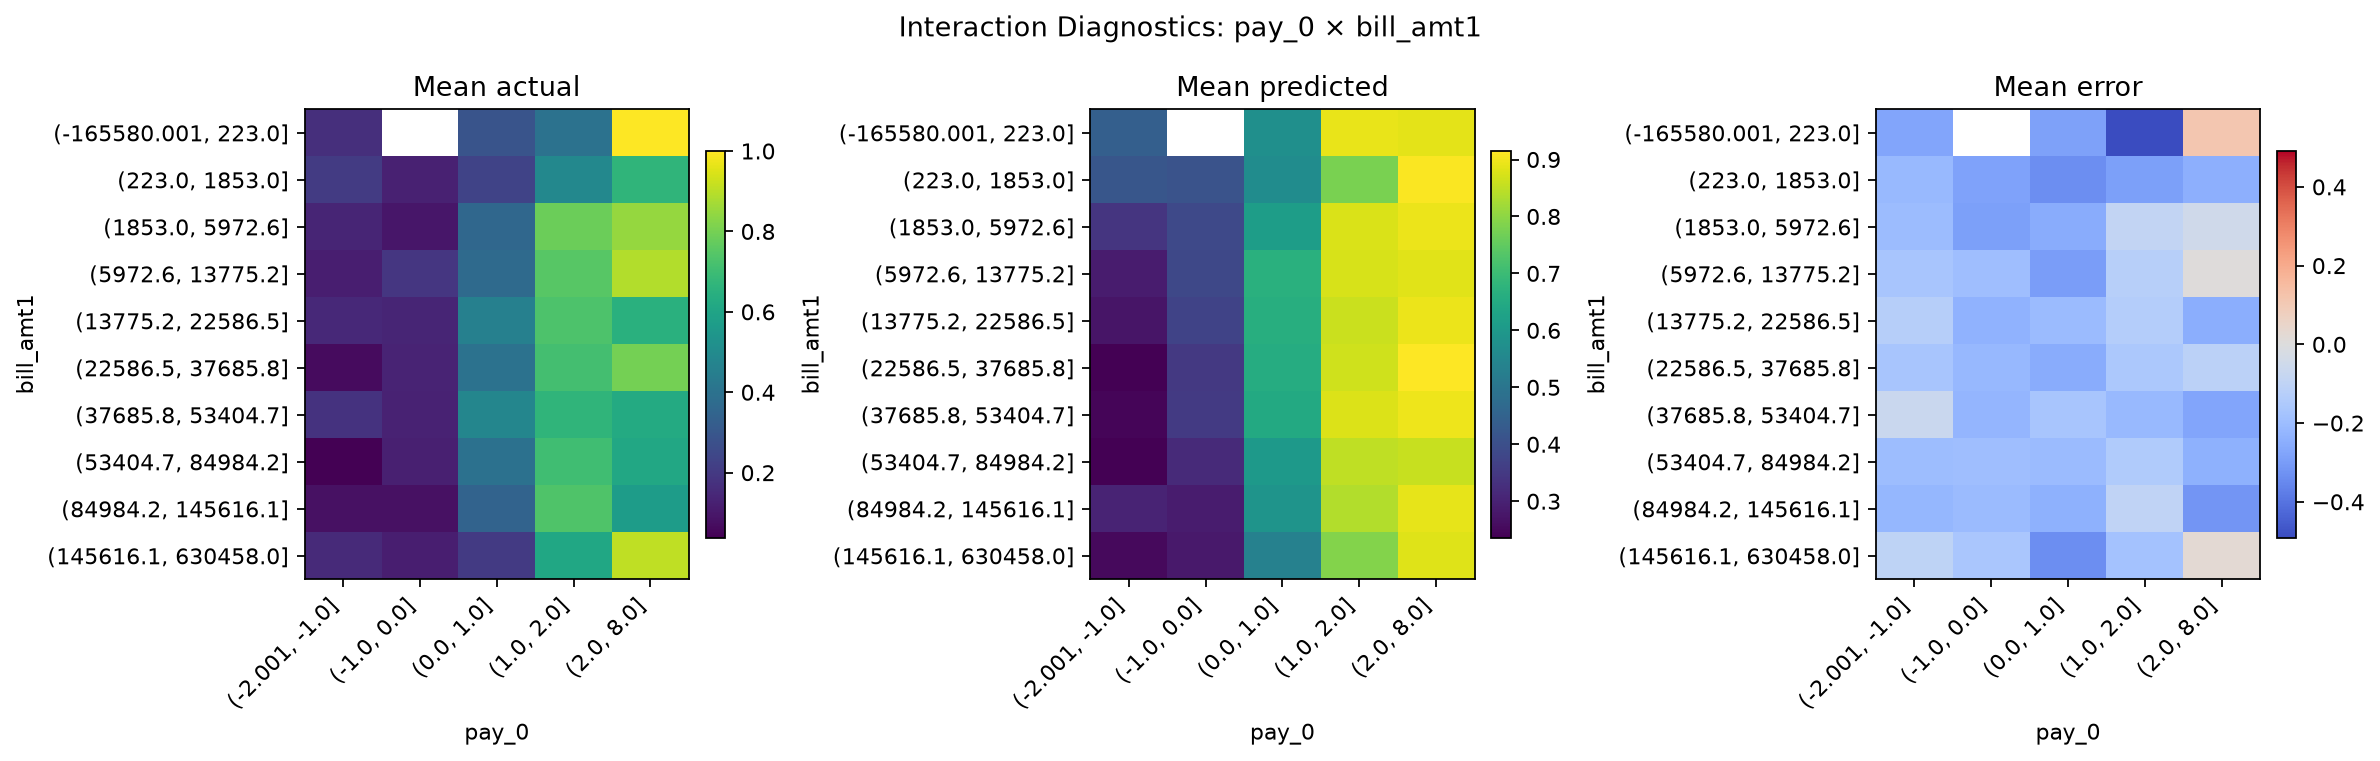

Saved interaction plot: notebooks\outputs\interaction_plots\pay_0__x__pay_amt5_interaction.png


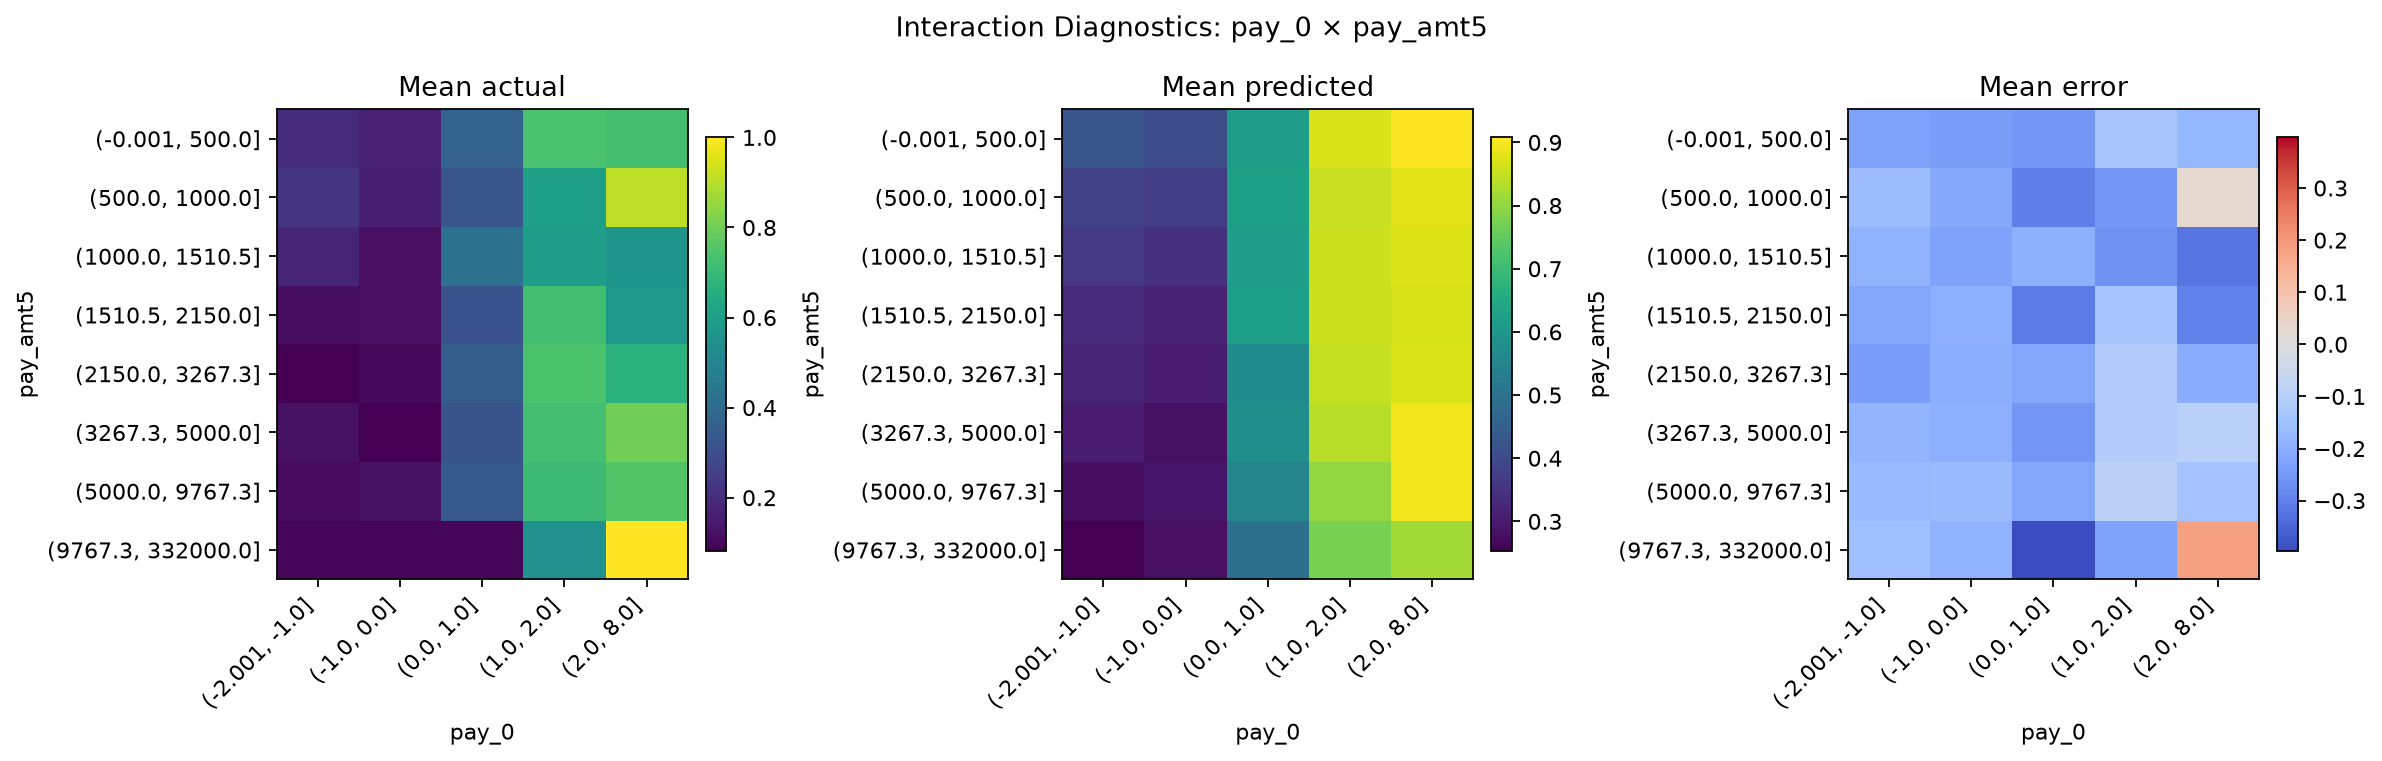

In [34]:
from IPython.display import Image, display

interaction_plot_dir = PROJECT_ROOT / 'notebooks' / 'outputs' / 'interaction_plots'
interaction_plot_dir.mkdir(parents=True, exist_ok=True)

interaction_figures = interaction_result.plot_top_interactions(
    top_n=3,
    save_dir=interaction_plot_dir,
)
for interaction_key, figure in interaction_figures.items():
    plot_path = interaction_plot_dir / f'{interaction_key}_interaction.png'
    print(f'Saved interaction plot: {plot_path.relative_to(PROJECT_ROOT)}')
    display(Image(filename=plot_path))
    plt.close(figure)


## Report export

Results can be exported to Excel and HTML. The notebook writes reports into `notebooks/outputs/`.


In [35]:
report_dir = PROJECT_ROOT / 'notebooks' / 'outputs'
report_dir.mkdir(parents=True, exist_ok=True)

excel_path = cv_result.to_excel(report_dir / 'uci_credit_residual_signal_report.xlsx')
html_path = cv_result.to_html(report_dir / 'uci_credit_residual_signal_report.html')

print(f'Wrote {excel_path.relative_to(PROJECT_ROOT)}')
print(f'Wrote {html_path.relative_to(PROJECT_ROOT)}')


Wrote notebooks\outputs\uci_credit_residual_signal_report.xlsx
Wrote notebooks\outputs\uci_credit_residual_signal_report.html


## v1 validation behavior

The current v1 finder intentionally rejects non-numeric feature columns and missing values. The original UCI fields are numeric, so the examples below inject bad inputs to demonstrate the guardrails.


In [36]:
try:
    ResidualSignalFinder(random_state=42).fit(
        X=X.assign(risk_bucket=np.where(y_true.eq(1), 'default', 'current')),
        y_true=y_true,
        y_pred=glm_y_pred,
    )
except ValueError as error:
    print(f'Categorical rejection: {error}')

try:
    X_missing = X.copy()
    X_missing.loc[X_missing.index[0], 'limit_bal'] = pd.NA
    ResidualSignalFinder(random_state=42).fit(
        X=X_missing,
        y_true=y_true,
        y_pred=glm_y_pred,
    )
except ValueError as error:
    print(f'Missing-value rejection: {error}')


Categorical rejection: categorical columns are not supported in v1; non-numeric columns: ['risk_bucket']
Missing-value rejection: missing values are not supported in v1
